This problem involves the Boston data set, which we saw in the lab for this chapter. We will now try to predict per capita crime rate using the other variables in this data set. In other words, per capita crime rate is the response, and the other variables are the predictors.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
!pip install ISLP
from ISLP import load_data

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [17]:
# Load Boston dataset (from sklearn or other source)
boston=load_data('Boston')
boston

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,6.48,22.0


In [18]:
response = 'crim'
predictors = [col for col in boston.columns if col != response]

### (a)

For each predictor, fit a simple linear regression model to predict the response. Describe your results. In which of the models is there a statistically significant association between the predictor and the response? Create some plots to back up your assertions.

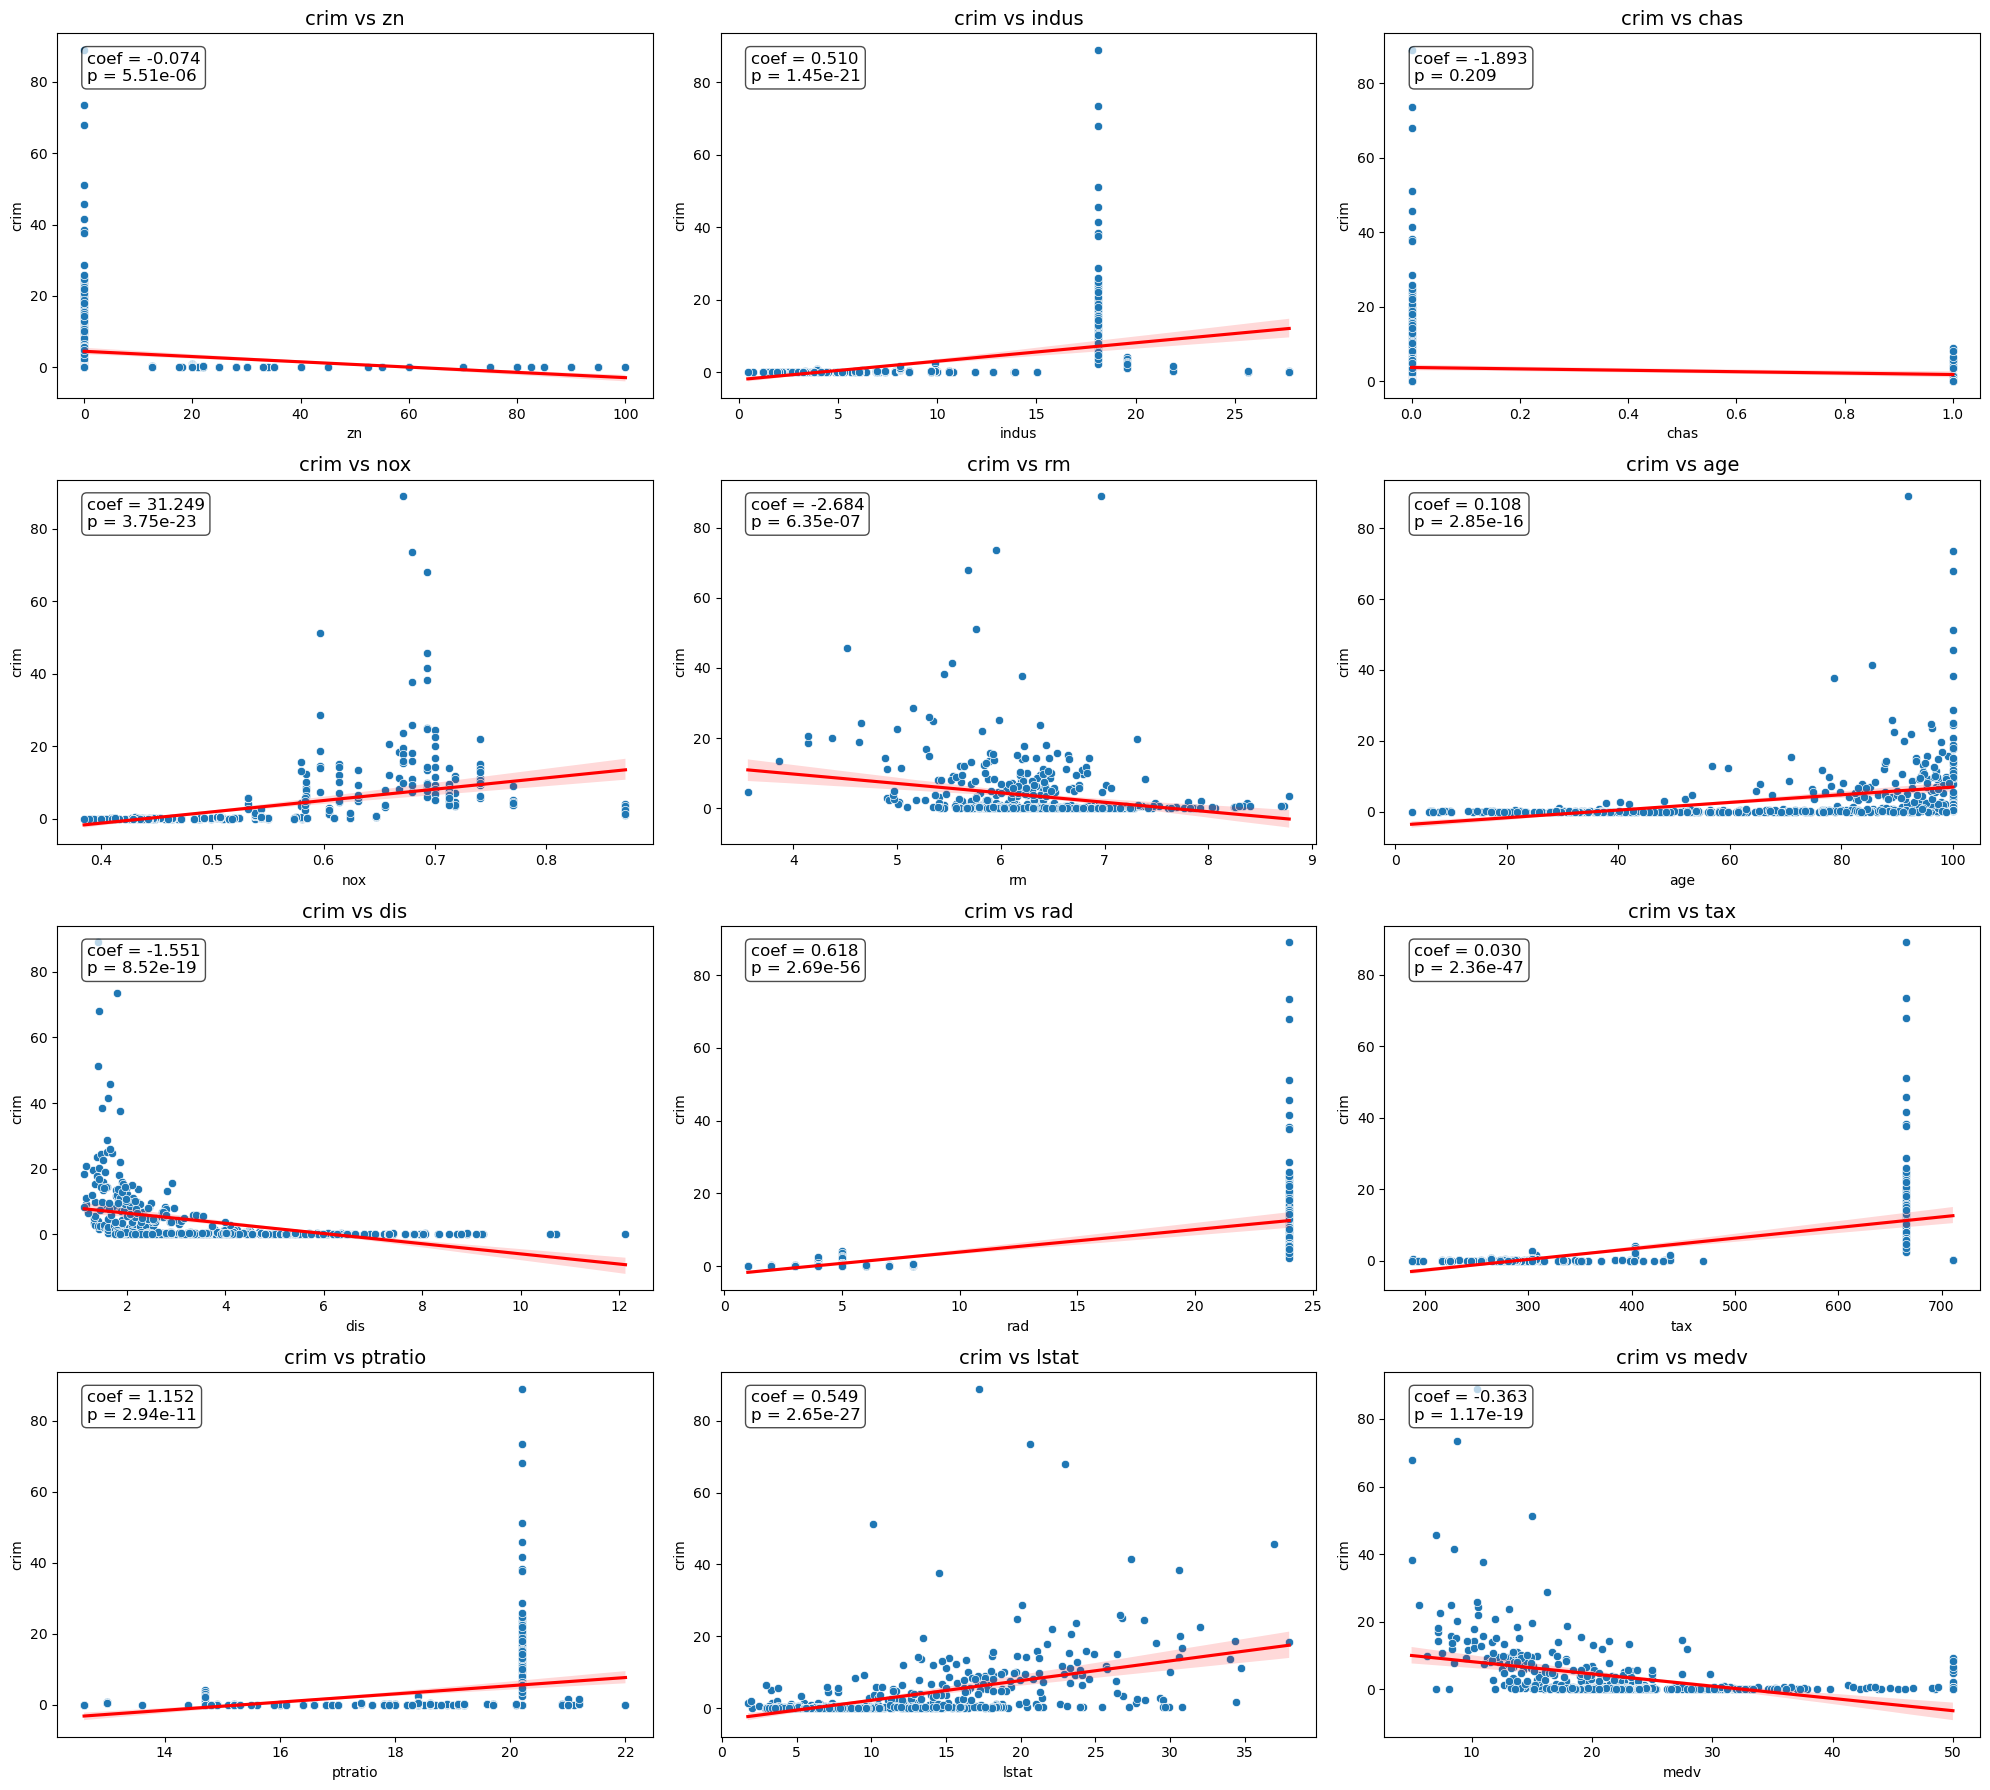

In [20]:
# 設定圖表
fig, axes = plt.subplots(4, 3, figsize=(20, 18))  # 4 rows x 3 cols
axes = axes.flatten()

# 儲存結果
simple_results = {}

# 畫圖迴圈
for i, pred in enumerate(predictors):
    formula = f"{response} ~ {pred}"
    model = smf.ols(formula, data=boston).fit()
    coef = model.params[pred]
    pval = model.pvalues[pred]
    simple_results[pred] = (coef, pval)

    # 繪圖
    ax = axes[i]
    sns.scatterplot(x=boston[pred], y=boston[response], ax=ax)
    sns.regplot(x=boston[pred], y=boston[response], scatter=False, ax=ax, color='red')
    ax.set_title(f"{response} vs {pred}", fontsize=14)
    ax.set_xlabel(pred)
    ax.set_ylabel(response)
    ax.text(0.05, 0.95, f"coef = {coef:.3f}\np = {pval:.3g}",
            transform=ax.transAxes, fontsize=12,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

# 隱藏多餘子圖
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Each variable is significant, but has obvious extreme values.

### (b)

Fit a multiple regression model to predict the response using all of the predictors. Describe your results. For which predictors can we reject the null hypothesis H0 : βj = 0?

In [23]:
#Fit a multiple regression with all predictors.
formula_all = f"{response} ~ " + " + ".join(predictors)
model_all = smf.ols(formula_all, data=boston).fit()
print("\nMultiple regression (all predictors):")
print(model_all.summary())

# Which predictors have p‑value < 0.05 (we reject H0: βj=0)
signif = [var for var, p in model_all.pvalues.items() if (p < 0.05 and var != 'Intercept')]
print("Significant predictors in the multiple regression:", signif)


Multiple regression (all predictors):
                            OLS Regression Results                            
Dep. Variable:                   crim   R-squared:                       0.449
Model:                            OLS   Adj. R-squared:                  0.436
Method:                 Least Squares   F-statistic:                     33.52
Date:                Sun, 19 Oct 2025   Prob (F-statistic):           2.03e-56
Time:                        17:01:33   Log-Likelihood:                -1655.4
No. Observations:                 506   AIC:                             3337.
Df Residuals:                     493   BIC:                             3392.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    

### (c)

How do your results from (a) compare to your results from (b)? Create a plot displaying the univariate regression coefficients from (a) on the x-axis, and the multiple regression coefficients from (b) on the y-axis. That is, each predictor is displayed as a single point in the plot. Its coefficient in a simple linear regres- sion model is shown on the x-axis, and its coefficient estimate in the multiple linear regression model is shown on the y-axis.

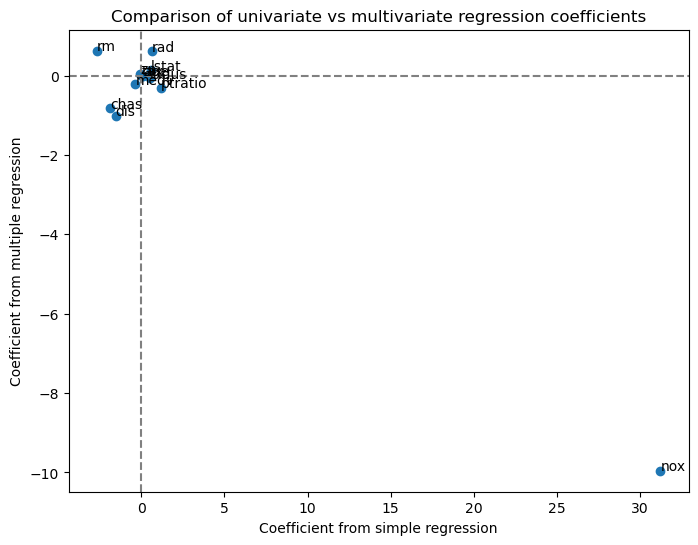

In [24]:
#Compare coefficients: plot univariate (a) vs multivariate (b)
multicoefs = model_all.params.drop('Intercept').reindex(predictors)
uni_coefs = pd.Series(simple_coefs).reindex(predictors)
plt.figure(figsize=(8,6))
plt.scatter(uni_coefs, multicoefs)
for i, var in enumerate(predictors):
    plt.text(uni_coefs[var], multicoefs[var], var)
plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')
plt.xlabel("Coefficient from simple regression")
plt.ylabel("Coefficient from multiple regression")
plt.title("Comparison of univariate vs multivariate regression coefficients")
plt.show()

### (d)

Is there evidence of non-linear association between any of the predictors and the response? To answer this question, for each predictor X, fit a model of the form <br>
$Y=β_{0}+β_{1}X+β_{2}X^{2}+β_{3}X^{3}+ε$.

In [28]:
# 儲存結果
poly_results = []

for pred in predictors:
    formula = f"{response} ~ {pred} + np.power({pred},2) + np.power({pred},3)"
    model = smf.ols(formula, data=boston).fit()
    
    # 取出係數與 p 值
    params = model.params
    pvalues = model.pvalues
    
    poly_results.append({
        'Predictor': pred,
        'Coef_X': round(params.get(pred, np.nan), 4),
        'Pval_X': round(pvalues.get(pred, np.nan), 4),
        'Coef_X2': round(params.get(f'np.power({pred}, 2)', np.nan), 4),
        'Pval_X2': round(pvalues.get(f'np.power({pred}, 2)', np.nan), 4),
        'Coef_X3': round(params.get(f'np.power({pred}, 3)', np.nan), 4),
        'Pval_X3': round(pvalues.get(f'np.power({pred}, 3)', np.nan), 4),
    })

# 轉為 DataFrame
poly_boston = pd.DataFrame(poly_results)

# 顯示結果
print(poly_boston)

   Predictor     Coef_X  Pval_X    Coef_X2  Pval_X2    Coef_X3  Pval_X3
0         zn    -0.3322  0.0026     0.0065   0.0938    -0.0000   0.2295
1      indus    -1.9652  0.0001     0.2519   0.0000    -0.0070   0.0000
2       chas    -0.6309  0.2094    -0.6309   0.2094    -0.6309   0.2094
3        nox -1279.3713  0.0000  2248.5441   0.0000 -1245.7029   0.0000
4         rm   -39.1501  0.2118     4.5509   0.3641    -0.1745   0.5086
5        age     0.2737  0.1427    -0.0072   0.0474     0.0001   0.0067
6        dis   -15.5544  0.0000     2.4521   0.0000    -0.1186   0.0000
7        rad     0.5127  0.6234    -0.0752   0.6130     0.0032   0.4823
8        tax    -0.1533  0.1097     0.0004   0.1375    -0.0000   0.2439
9    ptratio   -82.3605  0.0030     4.6353   0.0041    -0.0848   0.0063
10     lstat    -0.4491  0.3345     0.0558   0.0646    -0.0009   0.1299
11      medv    -5.0948  0.0000     0.1555   0.0000    -0.0015   0.0000


The variables indus, nox, dis, ptratio, and medv have significant nonlinear relationships with mpg.